In [81]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from matplotlib import colors as mcolors


import package_DBR
from package_DBR import myRound, SelectPath_RT, Delay_RT, FO_RT, FOPDT, SOPDT, FOPDT_cost, SOPDT_cost, Process, Bode

# Common Data

In [82]:
Ts = 1
e = np.exp(1)

# Load Data

In [ ]:
EXPERIENCE_NAME = "experience_01"

with open('Data/experiences.json', 'r') as f:
    db = json.load(f)

exp = next((e for e in db['experiences'] if e['namefile'] == EXPERIENCE_NAME), None)

if exp is None:
    raise ValueError(f"❌ Expérience '{EXPERIENCE_NAME}' introuvable dans le JSON.")

nameFile  = exp['datafile']
titleName = nameFile.split('.')[0]
data      = pd.read_csv('Data/' + nameFile)

if 'MV' in nameFile:
    ExpVariable = 'MV'
    tm  = data['tm'].values
    MVm = data['MVm'].values
    PVm = data['PVm'].values
else:
    ExpVariable = 'DV'
    tm  = data['tm'].values
    DVm = data['DVm'].values
    PVm = data['PVm'].values

print(f"📂 Fichier : {nameFile}  |  Variable : {ExpVariable}")

# ── Paramètres FOPDT optimisé ────────────────────────────────
Kp_OP_FOPDT    = exp['FOPDT_OPT']['Kp']
T_OP_FOPDT     = exp['FOPDT_OPT']['T']
Theta_OP_FOPDT = exp['FOPDT_OPT']['Theta']

print(f"\n📌 FOPDT OPT  →  Kp={Kp_OP_FOPDT},  T={T_OP_FOPDT},  Theta={Theta_OP_FOPDT}")

# ── Paramètres SOPDT optimisé ────────────────────────────────
Kp_OP_SOPDT    = exp['SOPDT_OPT']['Kp']
T1_OP_SOPDT    = exp['SOPDT_OPT']['T1']
T2_OP_SOPDT    = exp['SOPDT_OPT']['T2']
Theta_OP_SOPDT = exp['SOPDT_OPT']['Theta']

print(f"📌 SOPDT OPT  →  Kp={Kp_OP_SOPDT},  T1={T1_OP_SOPDT},  T2={T2_OP_SOPDT},  Theta={Theta_OP_SOPDT}")

# ── Paramètres graphiques ────────────────────────────────────
Kp_Graph = exp['Graph']['Kp']
a_Graph  = exp['Graph']['a']
Tu_Graph = exp['Graph']['Tu']
Tg_Graph = exp['Graph']['Tg']
t1_Graph = exp['Graph']['t1']
t2_Graph = exp['Graph']['t2']

print(f"📌 Graph      →  Kp={Kp_Graph},  a={a_Graph},  Tu={Tu_Graph},  Tg={Tg_Graph},  t1={t1_Graph},  t2={t2_Graph}") 

✅ Expérience chargée : experience_01
📂 Fichier : Cleaned_data_Open_loop_experiment_on_MV_2026-03-03-09h32.txt  |  Variable : MV

📌 FOPDT OPT  →  Kp=0.5354815066755887,  T=152.33873423438874,  Theta=36.73938820712028
📌 SOPDT OPT  →  Kp=0.5315977216868413,  T1=143.20962826230692,  T2=23.744697190626116,  Theta=17.394912344235067
📌 Graph      →  Kp=0.52,  a=0.18,  Tu=40,  Tg=156.67,  t1=86.67,  t2=116.67


# Comparaison des Modèles Optimisés

(0.0, 674.0)

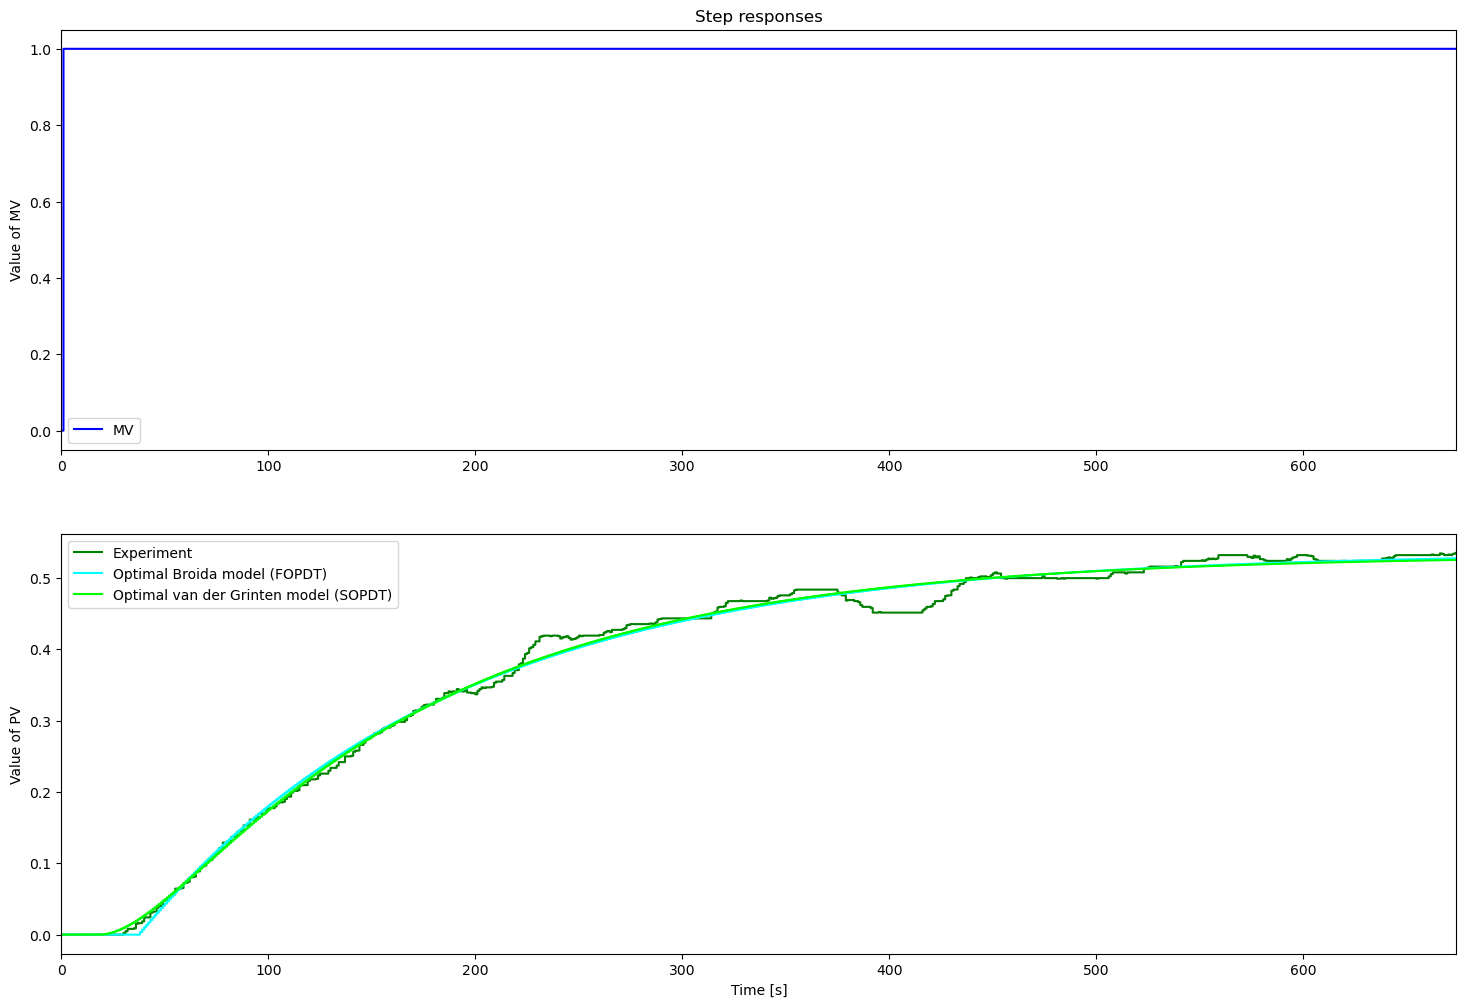

In [84]:
PV_SOPDTOPT = SOPDT(MVm,Kp_OP_SOPDT,T1_OP_SOPDT,T2_OP_SOPDT,Theta_OP_SOPDT,Ts)
PV_FOPDTOPT = FOPDT(MVm,Kp_OP_FOPDT,T_OP_FOPDT,Theta_OP_FOPDT,Ts)

plt.figure(figsize = (18,12))

plt.subplot(2,1,1)
plt.step(tm,MVm,'b-',label='MV',where='post')
plt.ylabel('Value of MV')
plt.title('Step responses')
plt.legend(loc='best')
plt.xlim([0, np.max(tm)])   

plt.subplot(2,1,2)
plt.step(tm,PVm,'g-',label='Experiment',where='post')
plt.step(tm,PV_FOPDTOPT,'cyan',label='Optimal Broida model (FOPDT)',where='post')
plt.step(tm,PV_SOPDTOPT,'lime',label='Optimal van der Grinten model (SOPDT)',where='post')
plt.ylabel('Value of PV')
plt.xlabel('Time [s]')
plt.legend(loc='best')  
plt.xlim([0, np.max(tm)])

Text(0, 0.5, 'Phase [°]')

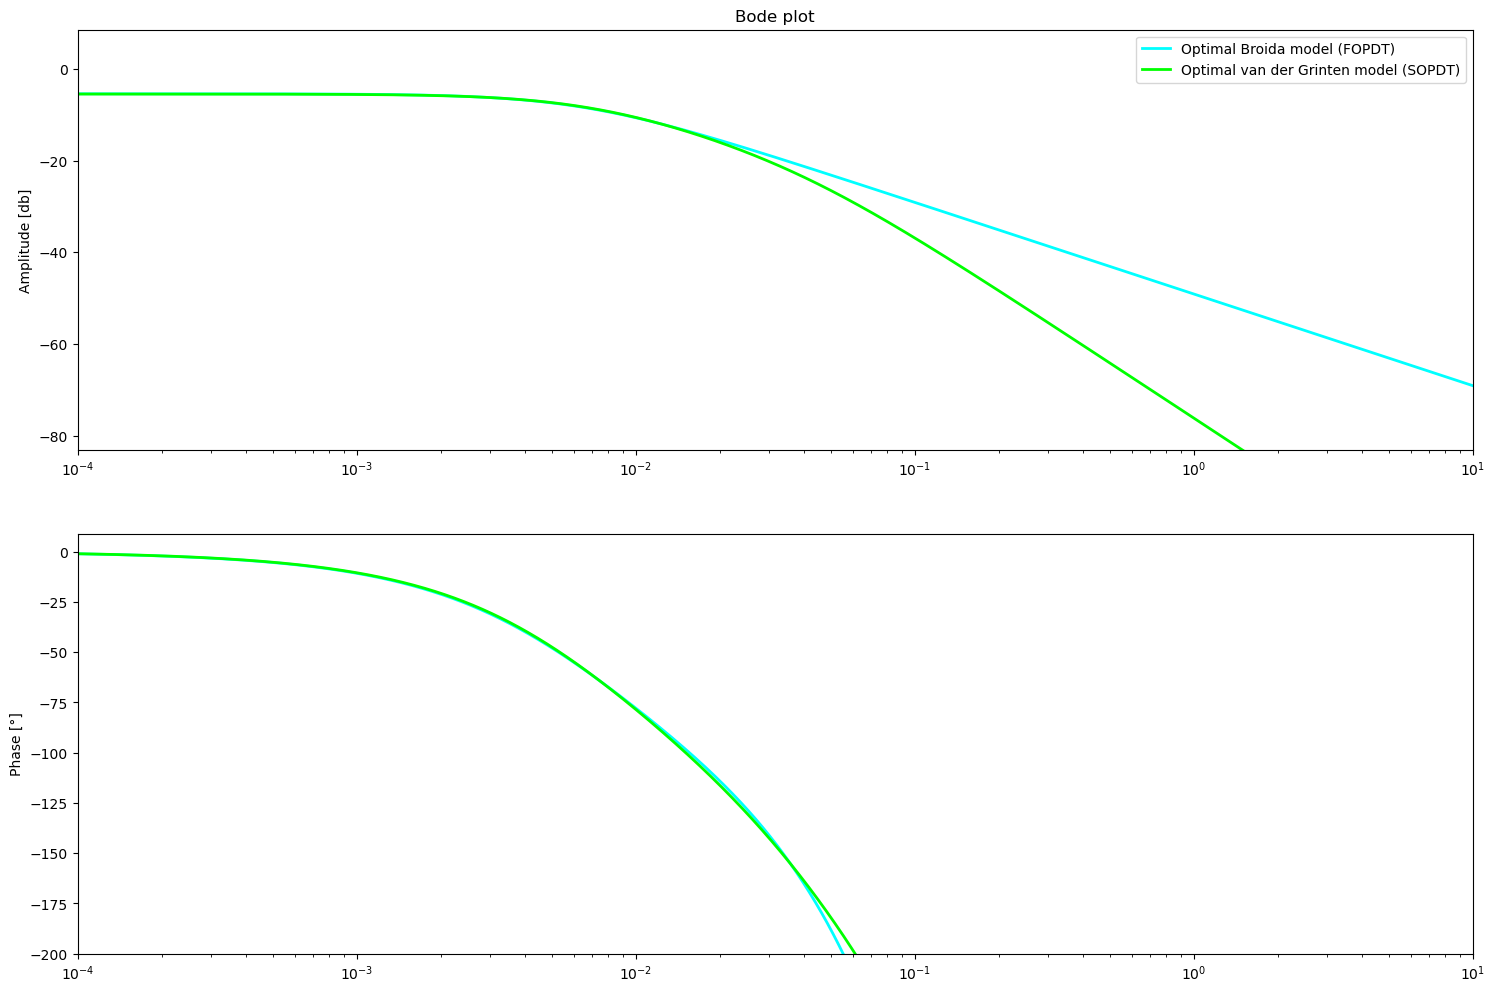

In [85]:
# Frequency response
P_FOPDTOPT = Process({})
P_FOPDTOPT.parameters['Kp'] = Kp_OP_FOPDT
P_FOPDTOPT.parameters['Tlag1'] = T_OP_FOPDT
P_FOPDTOPT.parameters['theta'] = Theta_OP_FOPDT

# Frequency response
P_SOPDTOPT = Process({})
P_SOPDTOPT.parameters['Kp'] = Kp_OP_SOPDT
P_SOPDTOPT.parameters['Tlag1'] = T1_OP_SOPDT
P_SOPDTOPT.parameters['Tlag2'] = T2_OP_SOPDT
P_SOPDTOPT.parameters['theta'] = Theta_OP_SOPDT

omega = np.logspace(-4, 1, 10000)
Ps_FOPDTOPT = Bode(P_FOPDTOPT,omega,False) # Optimal Broida
Ps_SOPDTOPT = Bode(P_SOPDTOPT,omega,False) # Optimal van der Grinten

plt.figure(figsize = (18,12))

plt.subplot(2,1,1)
gain_min = np.min(20*np.log10(np.abs(Ps_FOPDTOPT)/5))
gain_max = np.max(20*np.log10(np.abs(Ps_FOPDTOPT)*5))
plt.semilogx(omega,20*np.log10(np.abs(Ps_FOPDTOPT)),'cyan',linewidth=2,label='Optimal Broida model (FOPDT)')
plt.semilogx(omega,20*np.log10(np.abs(Ps_SOPDTOPT)),'lime',linewidth=2,label='Optimal van der Grinten model (SOPDT)')
plt.xlim([np.min(omega), np.max(omega)])
plt.ylim([gain_min, gain_max])
plt.ylabel('Amplitude [db]')
plt.title('Bode plot')
plt.legend(loc='best')

plt.subplot(2,1,2)
ph_min = np.min((180/np.pi)*np.unwrap(np.angle(Ps_FOPDTOPT))) - 10
ph_max = np.max((180/np.pi)*np.unwrap(np.angle(Ps_FOPDTOPT))) + 10
plt.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(Ps_FOPDTOPT)),'cyan',linewidth=2)
plt.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(Ps_SOPDTOPT)),'lime',linewidth=2)
plt.xlim([np.min(omega), np.max(omega)])
plt.ylim([np.max([ph_min, -200]), ph_max])
plt.ylabel('Phase [°]')

# Broida Model Parameter (FOPDT)

In [86]:
T_Broida_V1 = Tg_Graph
print(f"T_Broida_V1 : {T_Broida_V1:.4f}")
Theta_Broida_V1 = Tu_Graph
print(f"Theta_Broida_V1 : {Theta_Broida_V1:.4f}")
T_Broida_V2 = 5.5*(t2_Graph - t1_Graph)
print(f"T_Broida_V2 : {T_Broida_V2:.4f}")
Theta_Broida_V2 = 2.8*t1_Graph - 1.8*t2_Graph
print(f"Theta_Broida_V2 : {Theta_Broida_V2:.4f}")

T_Broida_V1 : 156.6700
Theta_Broida_V1 : 40.0000
T_Broida_V2 : 165.0000
Theta_Broida_V2 : 32.6700


# Grinten Model Parameter (SOPDT)

In [87]:
T1_Grinten = Tg_Graph*((3*a_Graph*e) - 1)/(1+(a_Graph*e))
print(f"T1_Grinten : {T1_Grinten:.4f}")
T2_Grinten = Tg_Graph*(1-(a_Graph*e))/(1+(a_Graph*e))
print(f"T2_Grinten : {T2_Grinten:.4f}")
Theta_Grinten = Tu_Graph - ((T1_Grinten*T2_Grinten)/(T1_Grinten + (3*T2_Grinten)))
print(f"Theta_Grinten : {Theta_Grinten:.4f}")

T1_Grinten : 49.2191
T2_Grinten : 53.7255
Theta_Grinten : 27.4317


# Strejc Model Parameter (NOPDT)

In [88]:
strejc_table = [
    (1, 0.00, 1.00),
    (2, 0.10, 2.72),
    (3, 0.22, 3.69),
    (4, 0.32, 4.46),
    (5, 0.41, 5.12),
    (6, 0.49, 5.70),
    (7, 0.57, 6.23),
]
ratio = Tu_Graph / Tg_Graph
n = None
a_n = None
b_n = None

for i in range(len(strejc_table) - 1):
    n_i,  a_i,  b_i  = strejc_table[i]
    n_i1, a_i1, b_i1 = strejc_table[i + 1]
    if a_i <= ratio < a_i1:
        n   = n_i
        a_n = a_i
        b_n = b_i
        break
if n is None:
    n, a_n, b_n = strejc_table[-1]
print(f"\nOrdre du système : n = {n}  (a_n = {a_n}, b_n = {b_n})")

# ── Étape 3 : constante de temps T ────────────────────────────
T_Strejc = Tg_Graph / b_n
print(f"\nConstante de temps : {T_Strejc:.4f}")

# ── Étape 4 : temps mort apparent T_uth ───────────────────────
T_uth_Strejc = a_n * Tg_Graph
print(f"Temps mort apparent : {T_uth_Strejc:.4f}")

# ── Étape 5 : délai réel θ ────────────────────────────────────
theta = Tu_Graph - T_uth_Strejc
print(f"Délai réel : {theta:.4f}")



Ordre du système : n = 3  (a_n = 0.22, b_n = 3.69)

Constante de temps : 42.4580
Temps mort apparent : 34.4674
Délai réel : 5.5326


# Comparaison des modèles obtenus par les différentes méthodes d'identification

⚠️  n=3 >= 3 : NOPDT_Strejc approché en SOPDT (T1=T2=T_Strejc)


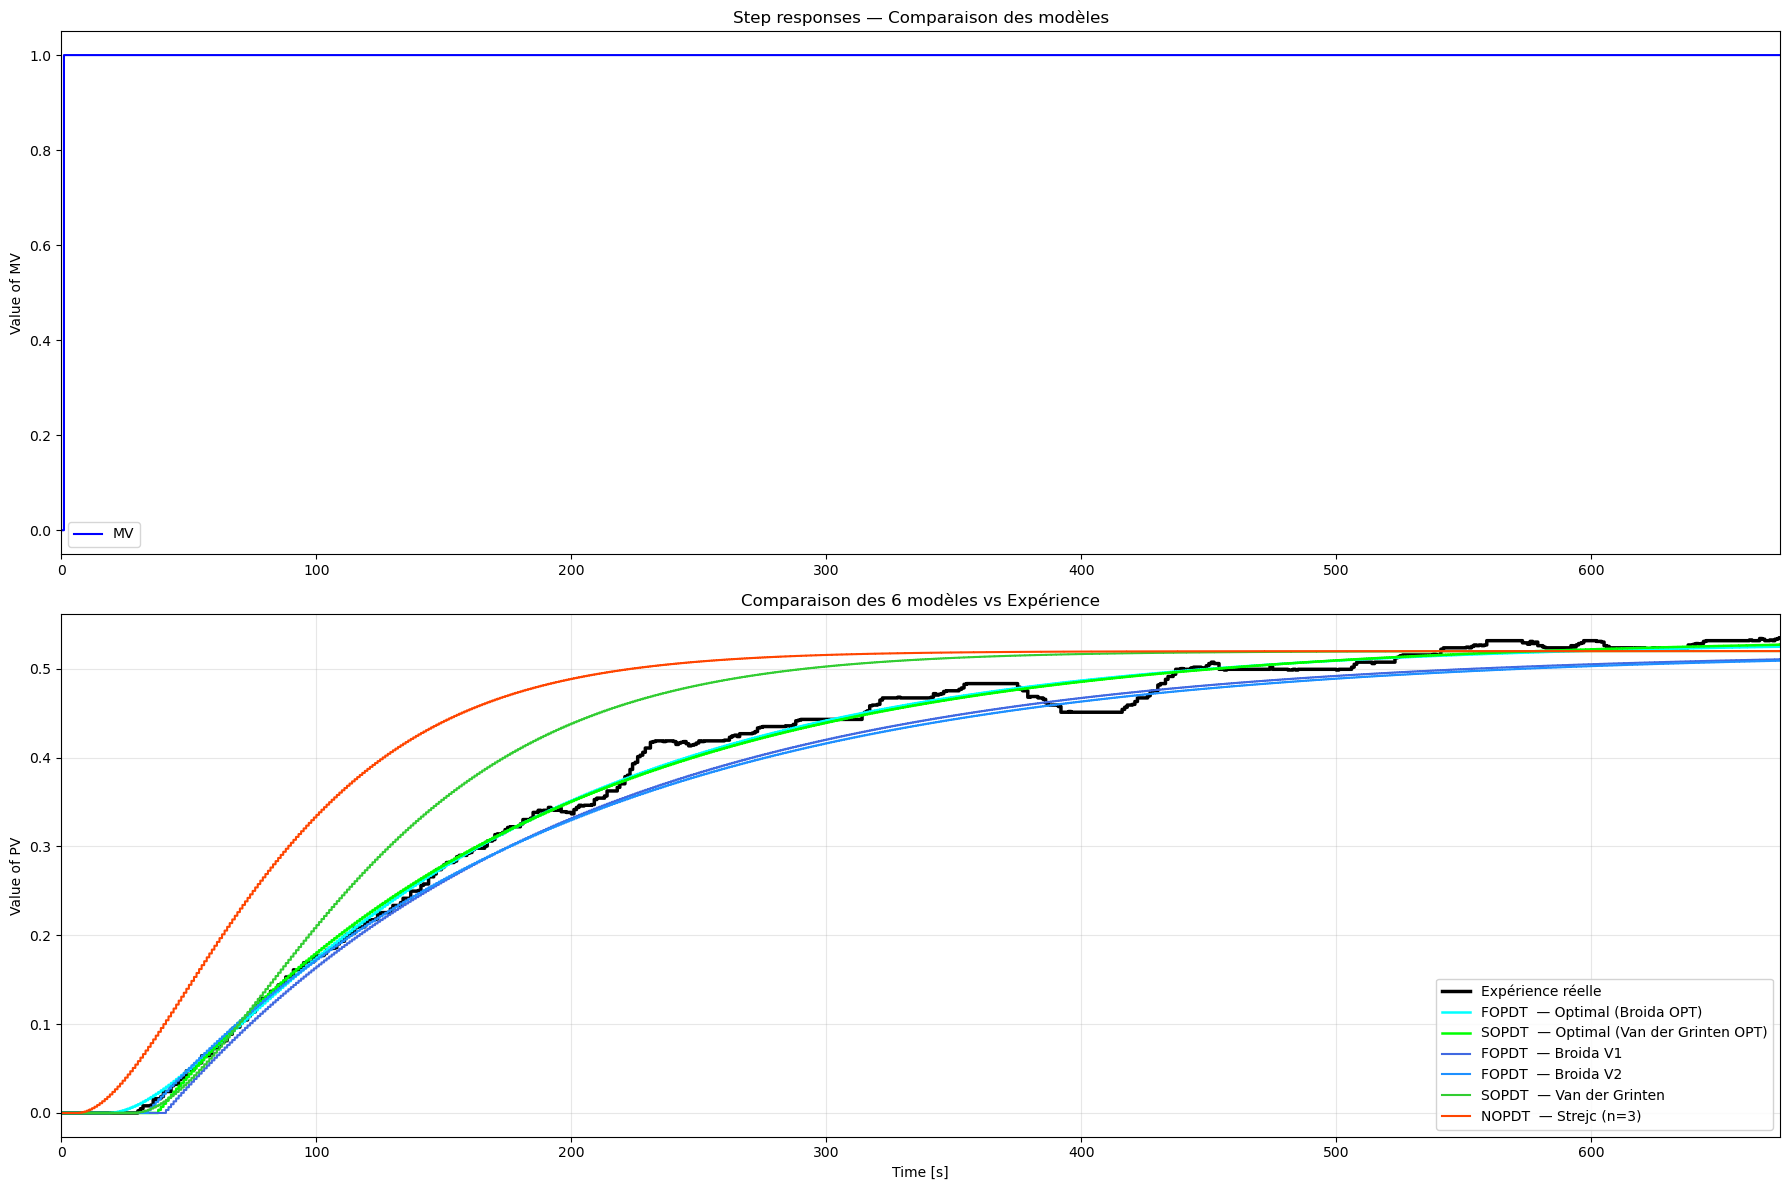

In [89]:
FOPDT_OPT = SOPDT(MVm,Kp_OP_SOPDT,T1_OP_SOPDT,T2_OP_SOPDT,Theta_OP_SOPDT,Ts)
SOPDT_OPT = FOPDT(MVm,Kp_OP_FOPDT,T_OP_FOPDT,Theta_OP_FOPDT,Ts)

FOPDT_Broida_V1 = FOPDT(MVm,Kp_Graph,T_Broida_V1,Theta_Broida_V1,Ts)
FOPDT_Broida_V2 = FOPDT(MVm,Kp_Graph,T_Broida_V2,Theta_Broida_V2,Ts)
SOPDT_Grinten = SOPDT(MVm,Kp_Graph,T1_Grinten,T2_Grinten,Theta_Grinten,Ts)
if n == 1:
    NOPDT_Strejc = FOPDT(MVm, Kp_Graph, T_Strejc, theta, Ts)
elif n == 2:
    NOPDT_Strejc = SOPDT(MVm, Kp_Graph, T_Strejc, T_Strejc, theta, Ts)
else:
    # Approximation SOPDT pour n >= 3
    NOPDT_Strejc = SOPDT(MVm, Kp_Graph, T_Strejc, T_Strejc, theta, Ts)
    print(f"⚠️  n={n} >= 3 : NOPDT_Strejc approché en SOPDT (T1=T2=T_Strejc)")


plt.figure(figsize=(18, 12))

# ── Subplot 1 : MV ────────────────────────────────────────────
plt.subplot(2, 1, 1)
plt.step(tm, MVm, 'b-', label='MV', where='post')
plt.ylabel('Value of MV')
plt.title('Step responses — Comparaison des modèles')
plt.legend(loc='best')
plt.xlim([0, np.max(tm)])

# ── Subplot 2 : PV — tous les modèles ────────────────────────
plt.subplot(2, 1, 2)

# Expérience réelle
plt.step(tm, PVm,             color='black',    linewidth=2.5,  label='Expérience réelle',                    where='post')

# Modèles optimaux
plt.step(tm, FOPDT_OPT,       color='cyan',     linewidth=1.8, label='FOPDT  — Optimal (Broida OPT)',         where='post')
plt.step(tm, SOPDT_OPT,       color='lime',     linewidth=1.8, label='SOPDT  — Optimal (Van der Grinten OPT)',where='post')

# Modèles Broida
plt.step(tm, FOPDT_Broida_V1, color='royalblue',linewidth=1.5, label='FOPDT  — Broida V1',                   where='post')
plt.step(tm, FOPDT_Broida_V2, color='dodgerblue',linewidth=1.5,label='FOPDT  — Broida V2',                   where='post')

# Modèle Van der Grinten
plt.step(tm, SOPDT_Grinten,   color='limegreen',linewidth=1.5, label='SOPDT  — Van der Grinten',             where='post')

# Modèle Strejc (ordre n)
plt.step(tm, NOPDT_Strejc,    color='orangered', linewidth=1.5, label=f'NOPDT  — Strejc (n={n})',             where='post')

plt.ylabel('Value of PV')
plt.xlabel('Time [s]')
plt.title('Comparaison des 6 modèles vs Expérience')
plt.legend(loc='best', fontsize=10, framealpha=0.85)
plt.xlim([0, np.max(tm)])
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Comparaison des diagrammes de bode obtenus par les différentes méthodes d'identification

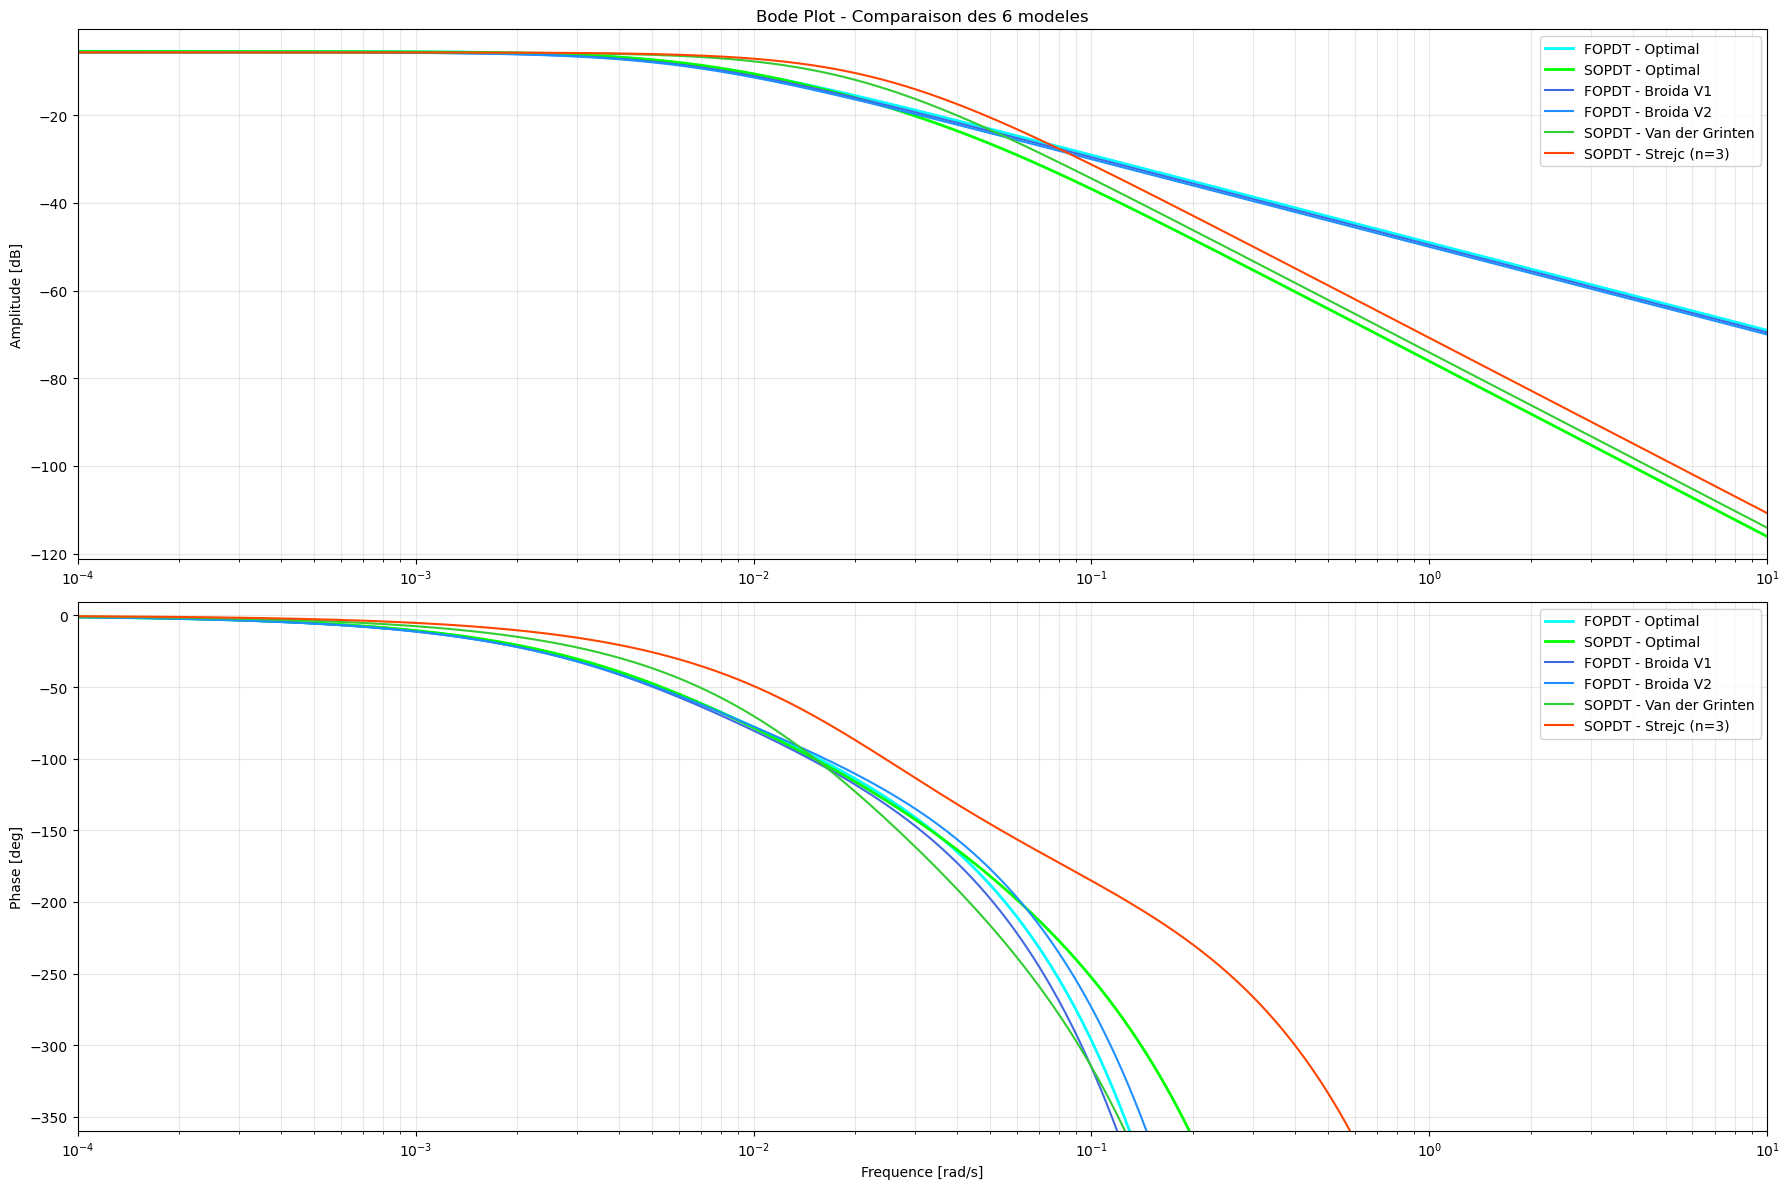

In [90]:
P_FOPDT_OPT = Process({})
P_FOPDT_OPT.parameters['Kp']    = Kp_OP_FOPDT
P_FOPDT_OPT.parameters['Tlag1'] = T_OP_FOPDT
P_FOPDT_OPT.parameters['theta'] = Theta_OP_FOPDT

P_SOPDT_OPT = Process({})
P_SOPDT_OPT.parameters['Kp']    = Kp_OP_SOPDT
P_SOPDT_OPT.parameters['Tlag1'] = T1_OP_SOPDT
P_SOPDT_OPT.parameters['Tlag2'] = T2_OP_SOPDT
P_SOPDT_OPT.parameters['theta'] = Theta_OP_SOPDT

P_Broida_V1 = Process({})
P_Broida_V1.parameters['Kp']    = Kp_Graph
P_Broida_V1.parameters['Tlag1'] = T_Broida_V1
P_Broida_V1.parameters['theta'] = Theta_Broida_V1

P_Broida_V2 = Process({})
P_Broida_V2.parameters['Kp']    = Kp_Graph
P_Broida_V2.parameters['Tlag1'] = T_Broida_V2
P_Broida_V2.parameters['theta'] = Theta_Broida_V2

P_Grinten = Process({})
P_Grinten.parameters['Kp']    = Kp_Graph
P_Grinten.parameters['Tlag1'] = T1_Grinten
P_Grinten.parameters['Tlag2'] = T2_Grinten
P_Grinten.parameters['theta'] = Theta_Grinten

P_Strejc = Process({})
P_Strejc.parameters['Kp']    = Kp_Graph
P_Strejc.parameters['Tlag1'] = T_Strejc
P_Strejc.parameters['Tlag2'] = T_Strejc
P_Strejc.parameters['theta'] = theta

omega = np.logspace(-4, 1, 10000)

Ps_FOPDT_OPT = Bode(P_FOPDT_OPT, omega, False)
Ps_SOPDT_OPT = Bode(P_SOPDT_OPT, omega, False)
Ps_Broida_V1 = Bode(P_Broida_V1, omega, False)
Ps_Broida_V2 = Bode(P_Broida_V2, omega, False)
Ps_Grinten   = Bode(P_Grinten,   omega, False)
Ps_Strejc    = Bode(P_Strejc,    omega, False)

# tuples : (ps, color, lw, label)
models = [
    (Ps_FOPDT_OPT, 'cyan',        2.0, 'FOPDT - Optimal'),
    (Ps_SOPDT_OPT, 'lime',        2.0, 'SOPDT - Optimal'),
    (Ps_Broida_V1, 'royalblue',   1.5, 'FOPDT - Broida V1'),
    (Ps_Broida_V2, 'dodgerblue',  1.5, 'FOPDT - Broida V2'),
    (Ps_Grinten,   'limegreen',   1.5, 'SOPDT - Van der Grinten'),
    (Ps_Strejc,    'orangered',   1.5, 'SOPDT - Strejc (n=' + str(n) + ')'),
]

all_gains  = np.concatenate([20*np.log10(np.abs(item[0])) for item in models])
all_phases = np.concatenate([(180/np.pi)*np.unwrap(np.angle(item[0])) for item in models])

gain_min = np.min(all_gains)  - 5
gain_max = np.max(all_gains)  + 5
ph_min   = max(np.min(all_phases) - 10, -360)
ph_max   = np.max(all_phases) + 10

plt.figure(figsize=(18, 12))

# Amplitude
plt.subplot(2, 1, 1)
for item in models:
    ps    = item[0]
    color = item[1]
    lw    = item[2]
    label = item[3]
    plt.semilogx(omega, 20*np.log10(np.abs(ps)),
                 color=color, linewidth=lw, label=label)
plt.axhline(0, color='white', linewidth=0.5, linestyle=':')
plt.xlim([np.min(omega), np.max(omega)])
plt.ylim([gain_min, gain_max])
plt.ylabel('Amplitude [dB]')
plt.title('Bode Plot - Comparaison des 6 modeles')
plt.legend(loc='best', fontsize=10, framealpha=0.85)
plt.grid(True, which='both', alpha=0.3)

# Phase
plt.subplot(2, 1, 2)
for item in models:
    ps    = item[0]
    color = item[1]
    lw    = item[2]
    label = item[3]
    plt.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(ps)),
                 color=color, linewidth=lw, label=label)

plt.xlim([np.min(omega), np.max(omega)])
plt.ylim([ph_min, ph_max])
plt.ylabel('Phase [deg]')
plt.xlabel('Frequence [rad/s]')
plt.legend(loc='best', fontsize=10, framealpha=0.85)
plt.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()